In [1]:
print("hi")

hi


In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [19]:
#defining the state for the graph
class batsman_analysis(TypedDict):
    name:str
    runs:int
    balls:int
    fours:int
    sixes:int
    sr:float
    bpb:float
    bp:float
    summary:str

In [20]:
# defining the graph
graph=StateGraph(batsman_analysis)

In [21]:
def strike_rate(state:batsman_analysis):
    runs=state['runs']
    balls=state['balls']
    sr=(runs/balls)*100
    return {'sr':sr}
    

def balls_per_boundary(state:batsman_analysis):
    balls=state['balls']
    fours=state['fours']
    sixes=state['sixes']
    bpb=(balls/(fours+sixes))
    return {'bpb':bpb}

def boundary_percentage(state:batsman_analysis):
    runs=state['runs']
    fours=state['fours']
    sixes=state['sixes']
    bp=(((fours*4)+(sixes*6))/runs)*100
    return {'bp':bp}

def batting_summary(state:batsman_analysis):
    name=state['name']
    runs=state['runs']
    balls=state['balls']
    fours=state['fours']
    sixes=state['sixes']
    sr=strike_rate(state)['sr']
    bpb=balls_per_boundary(state)['bpb']
    bp=boundary_percentage(state)['bp']
    summary=f'{name} scored {runs} runs of {balls} balls contributing {fours} fours and {sixes} sixes with a strike rate of {sr:.2f}, balls per boundary of {bpb:.2f} and boundary percentage of {bp:.2f}%.'

    return {"summary":summary}

In [22]:
# defining the nodes and edges

graph.add_node('strike_rate',strike_rate)
graph.add_node("balls_per_bundary",balls_per_boundary)
graph.add_node("boundary_percentage",boundary_percentage)
graph.add_node("batting_summary",batting_summary)

graph.add_edge(START,'strike_rate')
graph.add_edge(START,'balls_per_bundary')
graph.add_edge(START,'boundary_percentage')
graph.add_edge(['strike_rate','balls_per_bundary','boundary_percentage'],'batting_summary')
graph.add_edge('batting_summary',END)

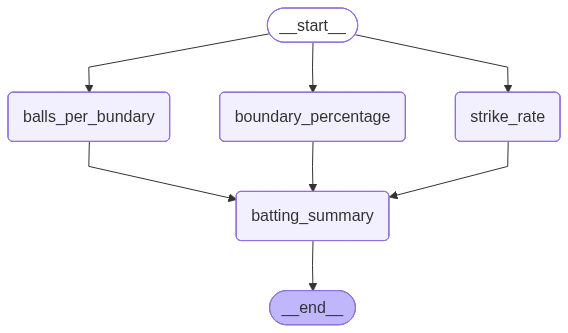

In [23]:
workflow=graph.compile()

workflow

In [24]:
initial_state={'name':'Virat Kohli','runs':100,'balls':50,'fours':6,'sixes':6}

output=workflow.invoke(initial_state)
output

{'name': 'Virat Kohli',
 'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 6,
 'sr': 200.0,
 'bpb': 4.166666666666667,
 'bp': 60.0,
 'summary': 'Virat Kohli scored 100 runs of 50 balls contributing 6 fours and 6 sixes with a strike rate of 200.00, balls per boundary of 4.17 and boundary percentage of 60.00%.'}

In [25]:
state=batsman_analysis(**output)
print(state)

{'name': 'Virat Kohli', 'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 6, 'sr': 200.0, 'bpb': 4.166666666666667, 'bp': 60.0, 'summary': 'Virat Kohli scored 100 runs of 50 balls contributing 6 fours and 6 sixes with a strike rate of 200.00, balls per boundary of 4.17 and boundary percentage of 60.00%.'}
